# Notebook \#2:</br> Exploratory Data Analysis

## 01 - Setup

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
# Notebook settings
%matplotlib inline  
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:.2f}'.format  # By default, display all floats with two decimals

## 02 - Data Exploration

In [3]:
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
df.head()

,charging_id,timestamp,minutes_elapsed,soc,power,energy,charger_category,nominal_power,temp,lat,lon,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,2020-01-11 12:37:00,0,40.00,89.44,0.32,Ultra,150.00,4,59.67,9.65,0.00,0.50,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,2020-01-11 12:38:00,1,41.00,92.75,1.84,Ultra,150.00,4,59.67,9.65,0.14,0.52,3.31,1.00,1.66,0.50,0.00,1.00,0.00
2,0,2020-01-11 12:39:00,2,43.00,94.81,3.41,Ultra,150.00,4,59.67,9.65,0.23,0.53,2.06,2.00,1.86,1.25,0.00,1.00,0.00
3,0,2020-01-11 12:40:00,3,45.00,95.68,5.00,Ultra,150.00,4,59.67,9.65,0.29,0.53,0.87,2.00,1.36,1.62,0.00,1.00,0.00
4,0,2020-01-11 12:41:00,4,47.00,96.88,6.60,Ultra,150.00,4,59.67,9.65,0.34,0.54,1.20,2.00,1.28,1.81,0.00,1.00,0.00


In [4]:
# Calculate some basic descriptive metrics
print("Shape: ", df.shape)
print("Number of charging sessions: ", len(pd.unique(df["charging_id"])))
print("Time interval: ", df["timestamp"].min(), " to ", df["timestamp"].max())
unique_locations = df[["lat", "lon"]].drop_duplicates()
print(f"There are {len(unique_locations)} different charging locations in the dataset.")
print("\nPandas .info(): ")
display(df.info())
print("\nPandas .describe(): ")
display(df.describe())

Shape:  (1594878, 20)
Number of charging sessions:  62039
Time interval:  2020-01-11 12:37:00  to  2024-11-03 19:32:00
There are 286 different charging locations in the dataset.

Pandas .info(): 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594878 entries, 0 to 1594877
Data columns (total 20 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   charging_id       1594878 non-null  int64         
 1   timestamp         1594878 non-null  datetime64[ns]
 2   minutes_elapsed   1594878 non-null  int64         
 3   soc               1594878 non-null  float64       
 4   power             1594878 non-null  float64       
 5   energy            1594878 non-null  float64       
 6   charger_category  1594878 non-null  category      
 7   nominal_power     1594878 non-null  float64       
 8   temp              1594878 non-null  int64         
 9   lat               1594878 non-null  float64       
 10  lon           

None


Pandas .describe(): 


,charging_id,timestamp,minutes_elapsed,soc,power,energy,nominal_power,temp,lat,lon,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
count,1594878.00,1594878,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00,1594878.00
mean,6229975.94,2022-12-15 01:24:17.235952128,15.25,60.77,87.04,22.29,172.51,7.50,60.78,8.36,0.51,0.48,-0.28,1.66,-0.19,1.60,0.15,0.76,0.09
min,0.00,2020-01-11 12:37:00,0.00,1.00,0.00,-0.01,50.00,-31.00,55.41,4.84,0.00,0.00,-152.18,-1.00,-75.77,-0.21,0.00,0.00,0.00
25%,3326011.00,2022-02-01 18:02:15,6.00,44.00,54.06,8.65,150.00,1.00,59.81,6.41,0.41,0.31,-1.95,1.00,-1.76,1.00,0.00,1.00,0.00
50%,5936958.00,2023-01-01 18:59:30,13.00,62.00,84.46,18.90,150.00,8.00,60.47,8.40,0.55,0.44,0.00,2.00,0.00,1.57,0.00,1.00,0.00
75%,9463776.00,2023-12-02 19:07:45,22.00,79.00,117.59,32.90,200.00,14.00,61.45,10.19,0.65,0.65,0.91,2.00,1.12,2.19,0.00,1.00,0.00
max,12657311.00,2024-11-03 19:32:00,160.00,100.00,267.79,158.47,500.00,31.00,69.76,24.12,1.00,1.00,160.50,9.00,80.25,6.00,1.00,1.00,1.00
std,3512205.03,NaN,12.49,22.01,36.20,16.66,75.58,9.19,1.66,2.35,0.19,0.22,7.09,0.95,4.57,0.77,0.36,0.43,0.29


#### Explanation of variables in the dataset
The dataset contains 1590144 measurements divided into 62,422 distinct charging sessions </br>for the Audi E-tron 55 EV. Each charging session was recorded at one of <a href="https://www.eviny.no/">Eviny</a>'s 286 charging stations. </br>
 - **`charging_id`, categorical, static (per session):**  The identifier for the entire charging session. A charging session is a single car, charging once at a single charging station. </br>
  - **`timestamp`, DateTime, piecewise continuous:** The date and time of each measurement (YYYY-mm-dd HH:MM:SS). The time-dependent variables are measured at one minute intervals. </br>
  - **`minutes_elapsed`, numerical, monotonic, time-dependent:** How many minutes have elapsed since the charging session began. This feature is calculated directly from the `timestamp` feature. </br>
  - **`power`, numerical, piecewise continuous, time-dependent:** The current power output in kW from the charging station to the car. </br>
 - **`soc`, numerical, piecewise continuous, time-dependent**: The State of Charge (SOC) of the car\'s battery as a percentage </br>
 - **`energy`, numerical, piecewise continuous, time-dependent:** The aggregate power delivered to the car in kWh over the course of the charging session. </br>
  - **`charging_duration`, numerical, discrete, static (per session):** How many minutes the charging session lasted. </br>
 - **`charger_category`, categorical, static (per session):** What type of charging station is being used to provide power to the vehicle. Values are *Ultra* or *Rapid*.
 - **`nominal_power`, ordinal, static (per session):** The maximum (nominal) power output in kW for the charging station. There are 22 different values ranging from 50 to 500 kW. </br>
  - **`temp`, numerical, discrete, static (per session):** The approximate ambient temperature in the area (corresponding to the nearest weather station). Even though the actual temperature may have fluctuated slightly over the course of the charging session, we took the temperature rounded to the nearest integer at the beginning of each session, and held it constant throughout the session. </br>
 - **`lat`, numerical, continuous, static (per session):** The latitude of the charging station. </br>
 - **`lon`, numerical, continuous, static (per session):** The longitude of the charging station.</br>

In [5]:
print(df["charger_category"].unique())
print(df["nominal_power"].unique())
print(len(df["nominal_power"].unique()))

['Ultra', 'Rapid']
Categories (2, object): ['Rapid', 'Ultra']
[150. 100.  50.  75.  90. 350.  62. 200. 180.  80. 360. 170. 140. 120.
 110. 240. 280. 400. 500. 300. 275. 115.]
22


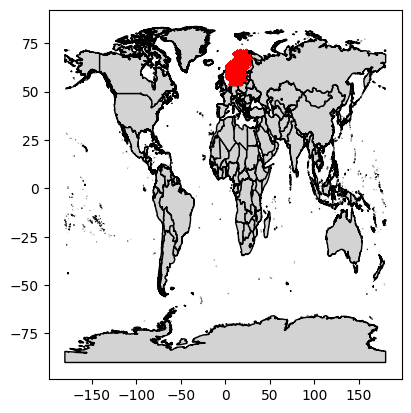

In [7]:
# Plot charging sessions on the world map
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"  # WGS84 Latitude/Longitude
)
# load world map downloaded from Natural Earth: https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/
world = gpd.read_file("../Data/map_data_for_plotting/ne_10m_admin_0_countries.shp")  
fig, ax = plt.subplots()
world.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, marker='x', color='red', markersize=30)
plt.savefig("../Images/EDA Plots/Charging_sessions_on_world_map.png", dpi=300, bbox_inches='tight')  # Save as PNG file
plt.show()

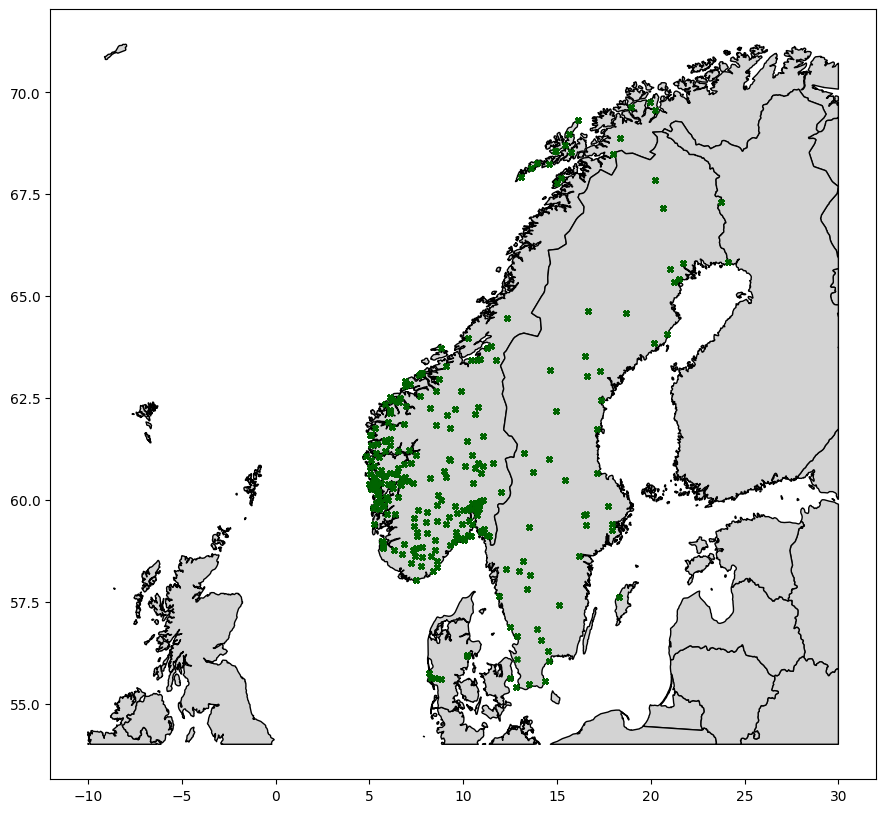

In [9]:
# Re-plot cropped map to see more detailed view
bbox = box(-10, 54, 30, 72)
clipped_world = gpd.clip(world, bbox)
fig, ax = plt.subplots(figsize=(15, 10))
clipped_world.plot(ax=ax, color='lightgrey', edgecolor='black')
gdf.plot(ax=ax, marker='x', color='darkgreen', markersize=10)
plt.savefig("../Images/EDA Plots/Charging_sessions_on_scandinavia_map.png")  # Save as PNG file
plt.show()
